In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.fluid      import Fluid
from src.interpolator import LinearInterpolator
from src.reservoir  import ResProps, Reservoir
from src.pipe       import Pipe
from src.well       import Well
from src.compressor import DCS
from src.simulator import FieldSimulator

plt.rcParams['axes.grid'] = True

In [23]:
M = 0.016
T_res = 310.0
df = pd.read_csv('hw2_data.csv', sep=';')
xa = df['xa, mol. %'].iloc[15] / 100
xy = df['xy, mol. %'].iloc[15] / 100
rho_c = df['rho_c, kg/m3'].iloc[15]

fluid = Fluid(M=M, rho_c=rho_c, xa=xa, xy=xy, T=T_res)

In [24]:
import math
roughness = 0.000046  # m

# Пласт (общий для всех трёх скважин)
P0    = 100.0   # atm
V_res = math.pi * 500**2 * 25   # m³

# NKT Скважины
nkt_1 = Pipe(L=2000, D=0.062, roughness=roughness, fluid=fluid, vertical_depth=1800)
nkt_2 = Pipe(L=2500, D=0.062, roughness=roughness, fluid=fluid, vertical_depth=1900)
nkt_3 = Pipe(L=1800, D=0.073, roughness=roughness, fluid=fluid, vertical_depth=1600)

# Скважины: [k, h, re, rw]
well_1 = Well(fluid=fluid, k=50, h=25, re=500, rw=0.1, pipe=nkt_1)
well_2 = Well(fluid=fluid, k=50, h=25, re=500, rw=0.1, pipe=nkt_2)
well_3 = Well(fluid=fluid, k=50, h=25, re=500, rw=0.1, pipe=nkt_3)
wells = [well_1, well_2, well_3]

# Шлейф
shlyf = Pipe(L=5000, D=0.200, roughness=roughness, fluid=fluid, vertical_depth=0)

# ДКС
CR     = 1.5
P_line = 5.0    # atm
q_ext  = 500.0  # ст.м³/сут
dcs   = DCS(CR=CR, P_line=P_line, q_ext=q_ext)

resprops = ResProps(P=P0, V=V_res, T=T_res)
reservoir = Reservoir(resprops=resprops, fluid=fluid)
simulate = FieldSimulator(reservoir=reservoir, wells=wells, shlyf=shlyf, dcs=dcs)

# Раздел 1 — Модель PVT

Графики Z(P), Bg(P), mu(P), ρ(P) в диапазоне 1–200 атм.

Сравнение ρ_ideal vs ρ_real

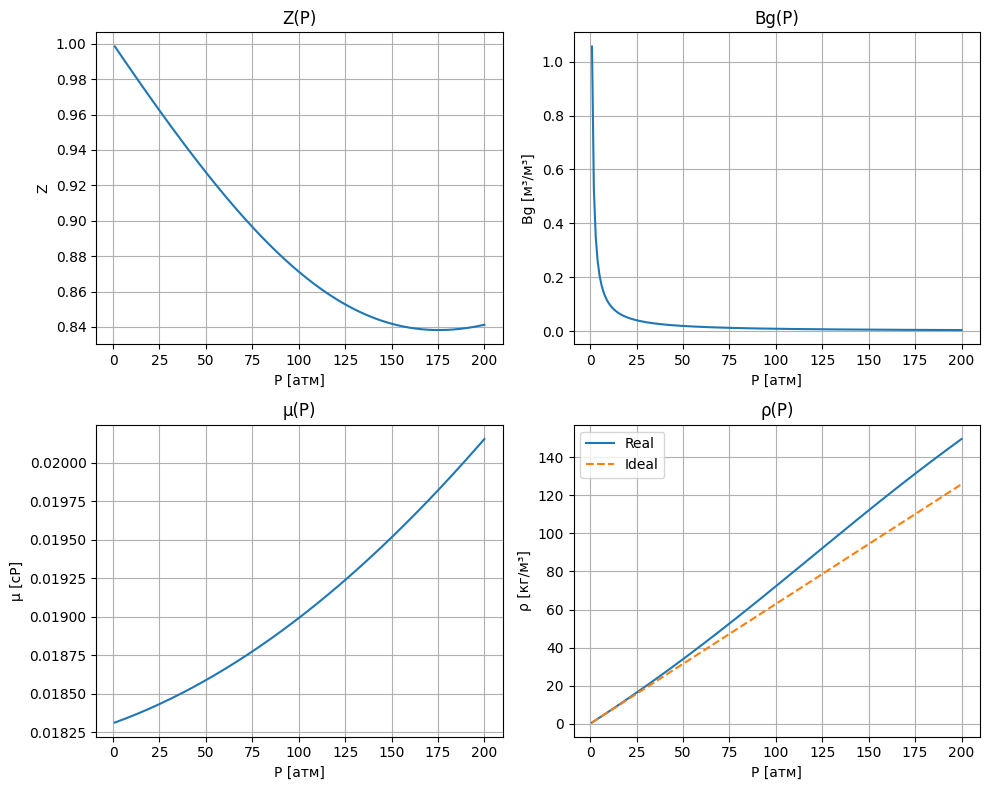

In [25]:
P_range = np.linspace(1, 200, 200)

Z_vals   = [fluid.z(P)   for P in P_range]
Bg_vals  = [fluid.bg(P)  for P in P_range]
mu_vals  = [fluid.mu(P)  for P in P_range]
rho_vals = [fluid.ro(P)  for P in P_range]

R = 8.314
rho_ideal = [P * 101325 * M / (1.0 * R * T_res) for P in P_range]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

#Графики Z(P), Bg(P), mu(P)
axes[0,0].plot(P_range, Z_vals);   axes[0,0].set(title='Z(P)', xlabel='P [атм]', ylabel='Z')
axes[0,1].plot(P_range, Bg_vals);  axes[0,1].set(title='Bg(P)', xlabel='P [атм]', ylabel='Bg [м³/м³]')
axes[1,0].plot(P_range, mu_vals);  axes[1,0].set(title='μ(P)', xlabel='P [атм]', ylabel='μ [cP]')
#ρ(P), cравнение ρ_ideal vs ρ_real
axes[1,1].plot(P_range, rho_vals, label='Real')
axes[1,1].plot(P_range, rho_ideal, '--', label='Ideal')
axes[1,1].set(title='ρ(P)', xlabel='P [атм]', ylabel='ρ [кг/м³]')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Раздел 2 — Модель пласта

кривая IPR при P_res = 100 атм для одной скважины.

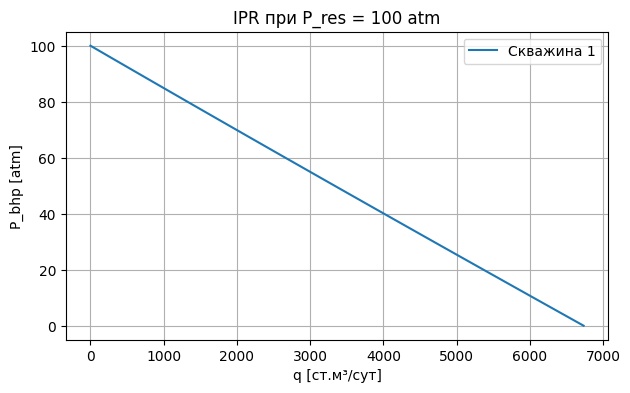

In [26]:
P_res = 100
P_bhp_range = np.linspace(0, P_res, 100)
q_ipr = [well_1.q(P_res, P_bhp) for P_bhp in P_bhp_range]

fig, axes = plt.subplots(figsize=(7, 4))
axes.plot(q_ipr, P_bhp_range, label=f'Скважина 1')
axes.set(xlabel='q [ст.м³/сут]', ylabel='P_bhp [atm]',
       title=f'IPR при P_res = {P_res} atm')
axes.legend()
plt.show()

# Раздел 3 — Гидравлика

кривые VLP трёх скважин и шлейфа. Зависимость λ(Re) по Колбруку–Уайту.

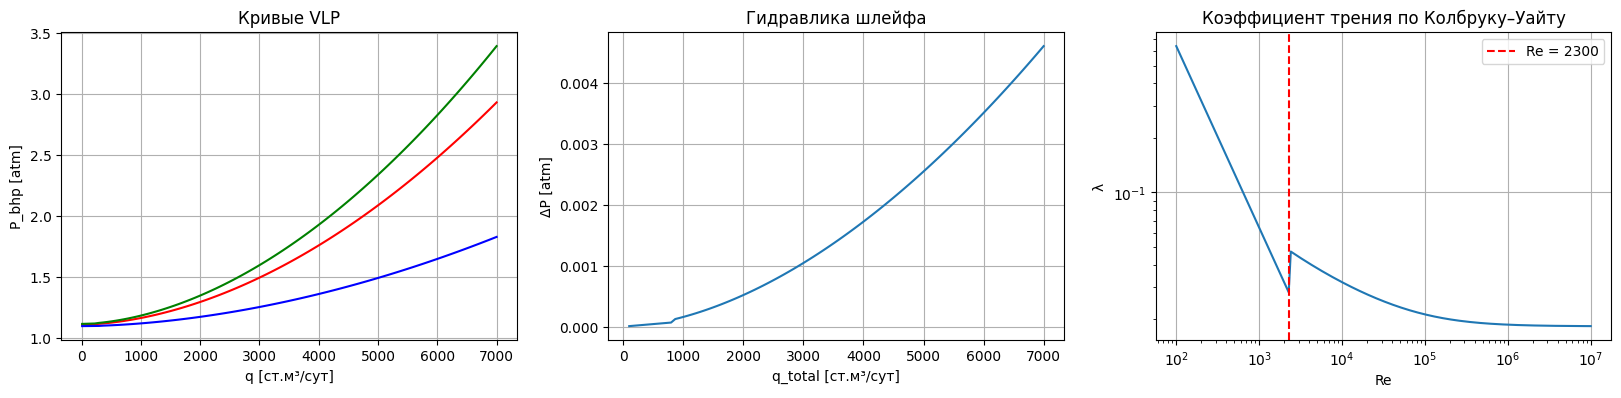

In [27]:
P_man = 1
q_range = np.linspace(10, 7000, 100)

vlp_1 = [P_man + nkt_1.dp(P_man, q).dP for q in q_range]
vlp_2 = [P_man + nkt_2.dp(P_man, q).dP for q in q_range]
vlp_3 = [P_man + nkt_3.dp(P_man, q).dP for q in q_range]

fig, axes = plt.subplots(1,3, figsize=(20, 4) )

axes[0].plot(q_range, vlp_1, 'r-', label='Скважина 1')
axes[0].plot(q_range, vlp_2, 'g-', label='Скважина 2')
axes[0].plot(q_range, vlp_3, 'b-', label='Скважина 3')
axes[0].set(xlabel='q [ст.м³/сут]', ylabel='P_bhp [atm]', title='Кривые VLP')

# VLP шлейфа
q_shlyf = np.linspace(100, 7000, 100)
dP_shlyf = [shlyf.dp(dcs.P_in(), q).dP for q in q_shlyf]

axes[1].plot(q_shlyf, dP_shlyf)
axes[1].set(xlabel='q_total [ст.м³/сут]', ylabel='ΔP [atm]', title='Гидравлика шлейфа')

# λ(Re)
Re_range = np.logspace(2, 7, 200)
lambda_vals = [nkt_1.f_lambda(Re) for Re in Re_range]

axes[2].loglog(Re_range, lambda_vals)
axes[2].axvline(2300, color='r', linestyle='--', label='Re = 2300')
axes[2].set(xlabel='Re', ylabel='λ', title='Коэффициент трения по Колбруку–Уайту')

plt.legend(); plt.show()





# Раздел 4 — Рабочая точка

графики IPR + VLP для каждой скважины с отмеченной рабочей точкой.

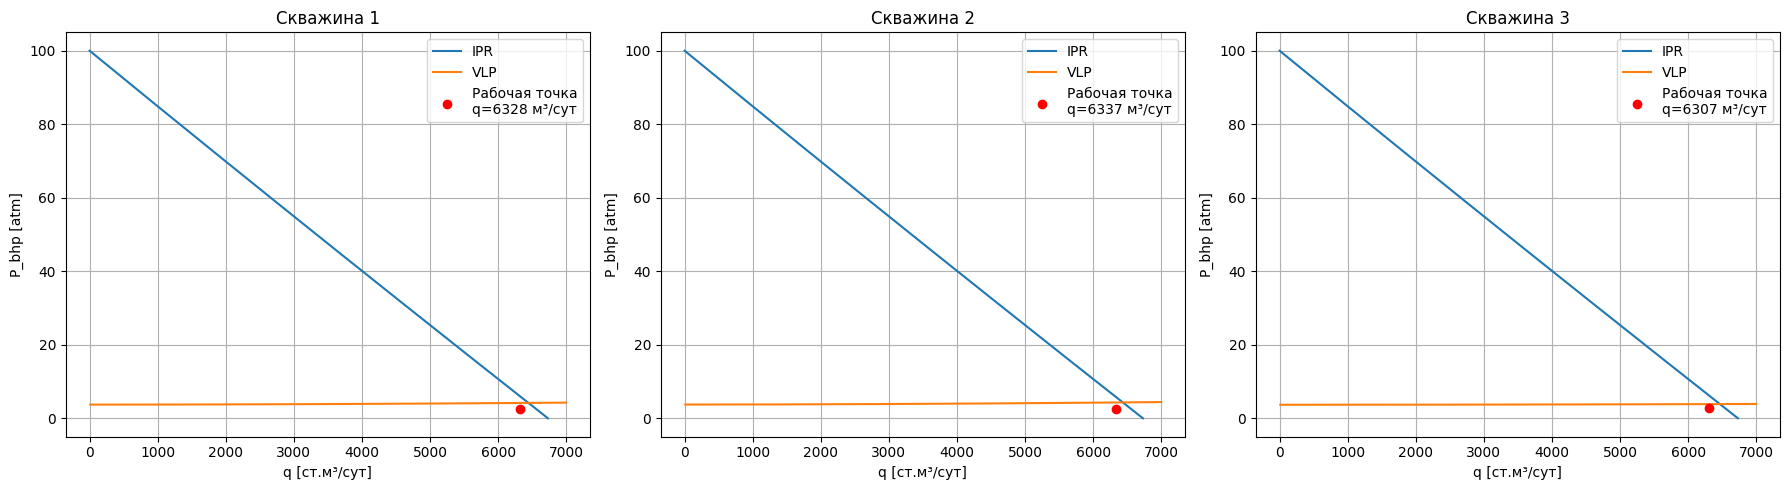

In [28]:
P0       = 100.0
states_0 = simulate.solve(P_res=P0)

P_bhp_range = np.linspace(0, P0, 200)
q_range     = np.linspace(10, 7000, 200)
fig, axes = plt.subplots(1,3, figsize=(18, 5))

# --- Скважина 1 ---
P_man_1   = states_0['well_1'].P_in
q_sol_1   = states_0['well_1'].q_std
P_bhp_sol_1 = states_0['well_1'].P_out

q_ipr_1     = [well_1.q(P0, Pb) for Pb in P_bhp_range]
P_bhp_vlp_1 = [P_man_1 + nkt_1.dp(P_man_1, q).dP for q in q_range]

axes[0].plot(q_ipr_1, P_bhp_range, label='IPR')
axes[0].plot(q_range, P_bhp_vlp_1, label='VLP')
axes[0].scatter([q_sol_1], [P_bhp_sol_1], color='red', zorder=5,
                label=f'Рабочая точка\nq={q_sol_1:.0f} м³/сут')
axes[0].set(title='Скважина 1', xlabel='q [ст.м³/сут]', ylabel='P_bhp [atm]')
axes[0].legend()

# --- Скважина 2 ---
P_man_2   = states_0['well_2'].P_in
q_sol_2   = states_0['well_2'].q_std
P_bhp_sol_2 = states_0['well_2'].P_out

q_ipr_2     = [well_2.q(P0, Pb) for Pb in P_bhp_range]
P_bhp_vlp_2 = [P_man_2 + nkt_2.dp(P_man_2, q).dP for q in q_range]

axes[1].plot(q_ipr_2, P_bhp_range, label='IPR')
axes[1].plot(q_range, P_bhp_vlp_2, label='VLP')
axes[1].scatter([q_sol_2], [P_bhp_sol_2], color='red', zorder=5,
                label=f'Рабочая точка\nq={q_sol_2:.0f} м³/сут')
axes[1].set(title='Скважина 2', xlabel='q [ст.м³/сут]', ylabel='P_bhp [atm]')
axes[1].legend()

# --- Скважина 3 ---
P_man_3   = states_0['well_3'].P_in
q_sol_3   = states_0['well_3'].q_std
P_bhp_sol_3 = states_0['well_3'].P_out

q_ipr_3     = [well_3.q(P0, Pb) for Pb in P_bhp_range]
P_bhp_vlp_3 = [P_man_3 + nkt_3.dp(P_man_3, q).dP for q in q_range]

axes[2].plot(q_ipr_3, P_bhp_range, label='IPR')
axes[2].plot(q_range, P_bhp_vlp_3, label='VLP')
axes[2].scatter([q_sol_3], [P_bhp_sol_3], color='red', zorder=5,
                label=f'Рабочая точка\nq={q_sol_3:.0f} м³/сут')
axes[2].set(title='Скважина 3', xlabel='q [ст.м³/сут]', ylabel='P_bhp [atm]')
axes[2].legend()

plt.tight_layout()
plt.show()

# Раздел 5 — Динамика 

графики Pres(t), Pman(t), q1(t), q2(t), q3(t), Gp(t) на 180 дней.

ЗАПУСК СИМУЛЯЦИИ
День   1 | P_res = 100.00 атм | q_total = 18972.53 м³ст/сут | Gp = 19.0 тыс. м³
День  10 | P_res = 100.00 атм | q_total = 18972.52 м³ст/сут | Gp = 189.7 тыс. м³
День  20 | P_res = 100.00 атм | q_total = 18972.50 м³ст/сут | Gp = 379.5 тыс. м³
День  30 | P_res = 100.00 атм | q_total = 18972.49 м³ст/сут | Gp = 569.2 тыс. м³
День  40 | P_res = 100.00 атм | q_total = 18972.47 м³ст/сут | Gp = 758.9 тыс. м³
День  50 | P_res = 100.00 атм | q_total = 18972.46 м³ст/сут | Gp = 948.6 тыс. м³
День  60 | P_res = 100.00 атм | q_total = 18972.44 м³ст/сут | Gp = 1138.3 тыс. м³
День  70 | P_res = 100.00 атм | q_total = 18972.43 м³ст/сут | Gp = 1328.1 тыс. м³
День  80 | P_res = 100.00 атм | q_total = 18972.41 м³ст/сут | Gp = 1517.8 тыс. м³
День  90 | P_res = 100.00 атм | q_total = 18972.40 м³ст/сут | Gp = 1707.5 тыс. м³
День 100 | P_res = 100.00 атм | q_total = 18972.38 м³ст/сут | Gp = 1897.2 тыс. м³
День 110 | P_res = 100.00 атм | q_total = 18972.36 м³ст/сут | Gp = 2087.0 тыс. м³
День 1

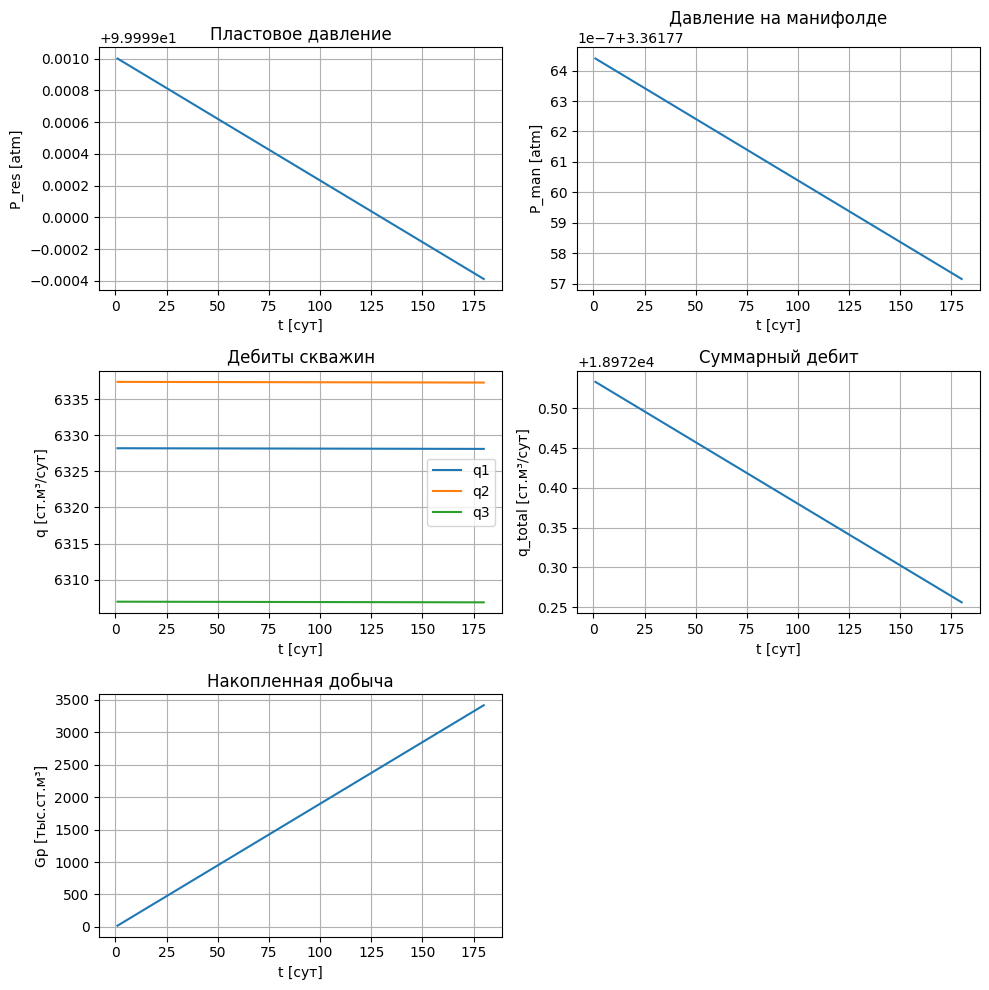

In [29]:
reservoir.resprops.P = P0

df = simulate.run(N_days=180, dt=1.0)

fig, axes = plt.subplots(3, 2, figsize=(10, 10))

axes[0,0].plot(df['t'], df['P_res'])
axes[0,0].set(ylabel='P_res [atm]', title='Пластовое давление')

axes[0,1].plot(df['t'], df['P_man'])
axes[0,1].set(ylabel='P_man [atm]', title='Давление на манифолде')

axes[1,0].plot(df['t'], df['q1'], label='q1')
axes[1,0].plot(df['t'], df['q2'], label='q2')
axes[1,0].plot(df['t'], df['q3'], label='q3')
axes[1,0].set(ylabel='q [ст.м³/сут]', title='Дебиты скважин')
axes[1,0].legend()

axes[1,1].plot(df['t'], df['q_total']); 
axes[1,1].set(ylabel='q_total [ст.м³/сут]', title='Суммарный дебит')

axes[2,0].plot(df['t'], df['Gp'])
axes[2,0].set(ylabel='Gp [тыс.ст.м³]', title='Накопленная добыча')

axes[2,1].axis('off')

for ax in axes.flat:
    ax.set_xlabel('t [сут]')
plt.tight_layout(); plt.show()

# Раздел 6 — Влияние ДКС

сравнение динамики при CR ∈ 1.0, 1.5, 2.0, 3.0.


ЗАПУСК СИМУЛЯЦИИ
День   1 | P_res = 100.00 атм | q_total = 18299.35 м³ст/сут | Gp = 18.3 тыс. м³
День  10 | P_res = 100.00 атм | q_total = 18299.34 м³ст/сут | Gp = 183.0 тыс. м³
День  20 | P_res = 100.00 атм | q_total = 18299.33 м³ст/сут | Gp = 366.0 тыс. м³
День  30 | P_res = 100.00 атм | q_total = 18299.31 м³ст/сут | Gp = 549.0 тыс. м³
День  40 | P_res = 100.00 атм | q_total = 18299.30 м³ст/сут | Gp = 732.0 тыс. м³
День  50 | P_res = 100.00 атм | q_total = 18299.28 м³ст/сут | Gp = 915.0 тыс. м³
День  60 | P_res = 100.00 атм | q_total = 18299.27 м³ст/сут | Gp = 1098.0 тыс. м³
День  70 | P_res = 100.00 атм | q_total = 18299.25 м³ст/сут | Gp = 1281.0 тыс. м³
День  80 | P_res = 100.00 атм | q_total = 18299.24 м³ст/сут | Gp = 1463.9 тыс. м³
День  90 | P_res = 100.00 атм | q_total = 18299.22 м³ст/сут | Gp = 1646.9 тыс. м³
День 100 | P_res = 100.00 атм | q_total = 18299.21 м³ст/сут | Gp = 1829.9 тыс. м³
День 110 | P_res = 100.00 атм | q_total = 18299.19 м³ст/сут | Gp = 2012.9 тыс. м³
День 1

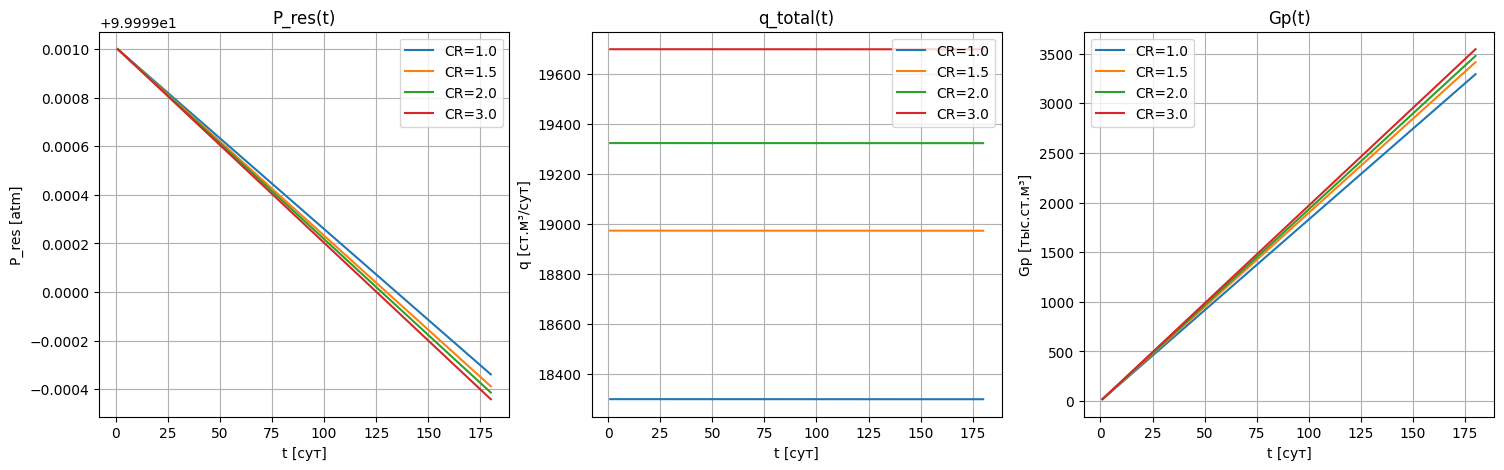

In [30]:
CR_values = [1.0, 1.5, 2.0, 3.0]
results_cr = {}

for cr in CR_values:
    reservoir.resprops.P = P0
    dcs.CR = cr
    df_cr = simulate.run(N_days=180, dt=1.0)
    results_cr[cr] = df_cr

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for cr, df_cr in results_cr.items():
    axes[0].plot(df_cr['t'], df_cr['P_res'],   label=f'CR={cr}')
    axes[1].plot(df_cr['t'], df_cr['q_total'], label=f'CR={cr}')
    axes[2].plot(df_cr['t'], df_cr['Gp'],      label=f'CR={cr}')

axes[0].set(title='P_res(t)', xlabel='t [сут]', ylabel='P_res [atm]')
axes[1].set(title='q_total(t)', xlabel='t [сут]', ylabel='q [ст.м³/сут]')
axes[2].set(title='Gp(t)', xlabel='t [сут]', ylabel='Gp [тыс.ст.м³]')
for ax in axes: 
    ax.legend()
plt.show()

dcs.CR = CR